In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
#import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'


In [2]:
mnt_pth = '/Volumes/FMac/computing/data/antarctica/' #mount path
pth_ismip6hack= mnt_pth + 'ismip6/hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6/hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6/hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'
# Generate loop_info DataFrame

In [3]:
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

In [4]:
models=[]
paths =[]
exps =[]
region_names = ['Amundsen','Ross','FilchnerRonne']
dic_sectors ={}
dic_sectors ['Amundsen']=np.array([4])
dic_sectors ['Ross']=np.array([2,6])
dic_sectors ['FilchnerRonne']=np.array([5,11])
for exp in expnames:
    lst = glob.glob(pth_ismip6hack+f'{exp}/dslc_anom/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
for i in range(1,4):
    df['region_'+str(i)]=0

for key in dic_sectors.keys():
    df[key] = 0
for i in range (df.shape[0]):
    pth_way = df.iloc[i].Path

    ##get shelf melt
    #pth_bmb = f'{pth_imip6hack}/{df.iloc[i].Experiment}/thermalforcing/computed_thermalforcing_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    
    # dSLC
    d = xr.open_dataset(pth_way,decode_times=False )

    ##BMB
    #d2 = xr.open_dataset(pth_bmb,decode_times=False )
    tmin= 285

    y = -1*d.dslc_anom.values[:tmin]
    m90times = d.time.values[:tmin][np.nanargmax(y)]
    df['AIS'].iloc[i]= m90times

    for j in range(1,19):
        y = -1*d['dslc_anom_sector_'+str(j)].values[:tmin]
        m90times = d.time.values[np.nanargmax(y)]
        df['sector_'+str(j)].iloc[i] = m90times

    for j in range(1,4):
        y = -1*d['dslc_anom_region_'+str(j)].values[:tmin]
        m90times = d.time.values[np.nanargmax(y)]
        df['region_'+str(j)].iloc[i] = m90times
        
    for key in dic_sectors.keys():
        dslc = 0
        for j in dic_sectors[key]:
            dslc = dslc-1*d['dslc_anom_sector_'+str(j)].values[:tmin]

        y = dslc
        m90times = d.time.values[np.nanargmax(y)]
        df[key].iloc[i]= m90times
#         df2['sector_'+str(j)].iloc[i] = x[:50].max()
#         if (j==1 and i ==4):
#             print(d2['iareafl_sector_'+str(j)].values[:tmin])
#             break


/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_10121/2951102086.py:45: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['AIS'].iloc[i]= m90times
/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_10121/2951102086.py:45: S

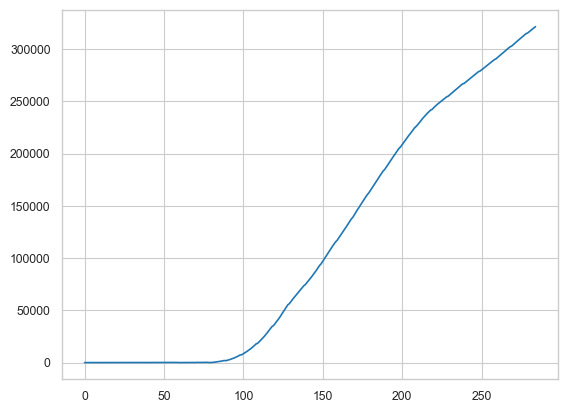

In [5]:
plt.plot(y)

In [6]:
df.to_csv('/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupBMBtodSLR/data_analysis/tables/time_maximum_dSLR.csv', index=False)

In [ ]:
df_sectors= df.copy()
df2 = df.copy()
df_sectors.drop(columns=['Experiment','Model','Path'], inplace=True)